<a href="https://colab.research.google.com/github/djwillichile/geoia-bloom-huasco/blob/main/notebooks/cartografia_huasco_layout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div align='center'>

# 🗺️ Layout Cartográfico — Cuenca del Huasco
**Elevación (SRTM) · NDVI medio (MODIS) · Cuenca · Región de Atacama**

</div>

## 0 · Dependencias
> Solo instala lo que falte — no requiere reiniciar el runtime.

In [13]:
import importlib.util, os

def install_if_missing(import_name, pip_name=None):
    if pip_name is None:
        pip_name = import_name
    if importlib.util.find_spec(import_name) is None:
        print(f'Instalando {pip_name}...')
        os.system(f'pip install -q {pip_name}')
        print(f'✅ {pip_name} instalado')
    else:
        print(f'✅ {pip_name} ya está disponible')

install_if_missing('ee',                  'earthengine-api')
install_if_missing('geemap',              'geemap')
install_if_missing('matplotlib_scalebar', 'matplotlib-scalebar')
install_if_missing('cartopy',             'cartopy')
install_if_missing('geopandas',           'geopandas')
install_if_missing('PIL',                 'Pillow')

✅ earthengine-api ya está disponible
✅ geemap ya está disponible
✅ matplotlib-scalebar ya está disponible
✅ cartopy ya está disponible
✅ geopandas ya está disponible
✅ Pillow ya está disponible


## 1 · Imports e inicialización de Earth Engine
> El proyecto se lee desde los **Secrets de Colab** (`🔑 → projectGEE`). Si no lo tienes configurado, reemplaza `userdata.get(...)` por el string de tu proyecto directamente.

In [20]:
import ee, geemap, numpy as np, warnings, requests
import geopandas as gpd
from shapely.geometry import shape
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.cm import ScalarMappable
from matplotlib_scalebar.scalebar import ScaleBar
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from google.colab import userdata
warnings.filterwarnings('ignore')

# ── Leer proyecto desde Secrets ───────────────────────────────────────────────
try:
    PROJECT_ID = userdata.get('projectGEE')
except Exception:
    PROJECT_ID = None

# Si no está en Secrets, pedir manualmente
if not PROJECT_ID:
    print('⚠️  No se encontró el Secret "projectGEE".')
    print('   Opciones:')
    print('   1) Agrega tu proyecto en el panel 🔑 (Secrets) con clave: projectGEE')
    print('   2) O ingrésalo manualmente a continuación:\n')
    PROJECT_ID = input('   Ingresa tu Google Cloud Project ID: ').strip()

# ── Inicializar Earth Engine ──────────────────────────────────────────────────
try:
    ee.Initialize(project=PROJECT_ID)
    print('✅ Earth Engine inicializado correctamente.')
except Exception:
    print('Autenticando...')
    ee.Authenticate()
    ee.Initialize(project=PROJECT_ID)
    print('✅ Earth Engine inicializado tras autenticación.')

✅ Earth Engine inicializado correctamente.


In [15]:
# ── Regiones de contexto (Atacama y Coquimbo) ─────────────────────────────────
regiones = (
    ee.FeatureCollection('FAO/GAUL/2015/level1')
    .filter(ee.Filter.eq('ADM0_NAME', 'Chile'))
    .filter(ee.Filter.inList('ADM1_NAME', ['Atacama', 'Coquimbo']))
)

# ── Provincia y cuenca del Huasco ─────────────────────────────────────────────
gaul = ee.FeatureCollection('FAO/GAUL/2015/level2')

huasco_prov = (
    gaul
    .filter(ee.Filter.eq('ADM0_NAME', 'Chile'))
    .filter(ee.Filter.eq('ADM2_NAME', 'Huasco'))
    .geometry()
)

outlet       = ee.Geometry.Point([-71.17, -28.47])
basins       = ee.FeatureCollection('WWF/HydroSHEDS/v1/Basins/hybas_6')
huasco_basin = ee.Feature(basins.filterBounds(outlet).first()).geometry()

# ── AOI: unión provincia + cuenca con buffer 5 km ─────────────────────────────
AOI = huasco_basin.union(huasco_prov).bounds().buffer(5000).bounds()

# ── GeoDataFrames ─────────────────────────────────────────────────────────────
huasco_gdf = gpd.GeoDataFrame(
    geometry=[shape(huasco_basin.getInfo())],
    crs='EPSG:4326'
)
regiones_gdf = gpd.GeoDataFrame(
    geometry=[shape(f['geometry']) for f in regiones.getInfo()['features']],
    crs='EPSG:4326'
)

# ── Ríos HydroSHEDS (orden 1–5) ───────────────────────────────────────────────
# RIV_ORD: 1 = río más grande, 10 = más pequeño
# Bajar a lte(7) si faltan ríos, subir a lte(4) si hay exceso
rios_region = (
    ee.FeatureCollection('WWF/HydroSHEDS/v1/FreeFlowingRivers')
    .filterBounds(regiones.geometry())
    .filter(ee.Filter.lte('RIV_ORD', 5))
    .limit(500)
)
rios_gdf = gpd.GeoDataFrame(
    geometry=[shape(f['geometry']) for f in rios_region.getInfo()['features']],
    crs='EPSG:4326'
)

print(f'Regiones    — features: {len(regiones_gdf)}')   # debe ser 2
print(f'Prov Huasco — área > 0: {huasco_prov.area().getInfo() > 0}')
print(f'Ríos región — features: {len(rios_gdf)}')
print('✅ Geometrías y AOI listos')

Regiones    — features: 2
Prov Huasco — área > 0: True
Ríos región — features: 41
✅ Geometrías y AOI listos


## 3 · Capas GEE — DEM hillshade y NDVI

In [16]:
# ── DEM + Hillshade (SRTM 30 m) ───────────────────────────────────────────────
dem       = ee.Image('USGS/SRTMGL1_003').clip(AOI)
hillshade = ee.Terrain.hillshade(dem)

elev_vis = {
    'min': -120, 'max': 4600,
    'palette': [
        '#9fc5e8', '#006837', '#1a9850', '#66bd63', '#a6d96a',
        '#d9ef8b', '#ffffbf', '#fee08b', '#fdae61', '#f46d43',
        '#d73027', '#b2182b', '#f46d43', '#d73027', '#b2182b',
        '#f6e8c3', '#f5f5f5'
    ]
}

rgb    = dem.visualize(**elev_vis)
shaded = ee.Image.rgb(
    rgb.select(0).multiply(hillshade.divide(255)),
    rgb.select(1).multiply(hillshade.divide(255)),
    rgb.select(2).multiply(hillshade.divide(255))
)

# ── NDVI medio período de floración ───────────────────────────────────────────
# ⚠️ Ajusta meses según tu análisis del desierto florido
MONTH_START, MONTH_END = 7, 10
YEAR_START,  YEAR_END  = 2002, 2023

ndvi_mean = (
    ee.ImageCollection('MODIS/061/MOD13Q1')
    .filterDate(f'{YEAR_START}-01-01', f'{YEAR_END}-12-31')
    .filter(ee.Filter.calendarRange(MONTH_START, MONTH_END, 'month'))
    .select('NDVI')
    .map(lambda img: img.multiply(0.0001))
    .mean()
    .clip(AOI)
)

# ── NDVI enmascarado a la cuenca + hillshade ──────────────────────────────────
vis_ndvi = {
    'min': 0.0, 'max': 0.9,
    'palette': [
        '#ffffff', '#ce7e45', '#df923d', '#f1b555', '#fcd163', '#99b718',
        '#74a901', '#66a000', '#529400', '#3e8601', '#207401', '#056201',
        '#004c00', '#023b01', '#012e01', '#011d01', '#011301'
    ]
}

ndvi_cuenca = ndvi_mean.updateMask(
    ee.Image.constant(1).clip(huasco_basin).mask()
)
ndvi_rgb = ndvi_cuenca.visualize(**vis_ndvi)
ndvi_shaded = ee.Image.rgb(
    ndvi_rgb.select(0).multiply(hillshade.divide(255)),
    ndvi_rgb.select(1).multiply(hillshade.divide(255)),
    ndvi_rgb.select(2).multiply(hillshade.divide(255))
)

print('✅ DEM con hillshade y NDVI procesados.')

✅ DEM con hillshade y NDVI procesados.


## 4 · Descarga de arrays
> `shaded` y `ndvi_shaded` via `getThumbURL`. DEM escalar a 500 m para curvas de nivel.

In [17]:
RES_DEM = 200

# ── Extensión del AOI ─────────────────────────────────────────────────────────
aoi_coords = AOI.bounds().getInfo()['coordinates'][0]
lons = [c[0] for c in aoi_coords]
lats = [c[1] for c in aoi_coords]
dem_ext  = [min(lons), max(lons), min(lats), max(lats)]
ndvi_ext = dem_ext

# ── Shaded DEM via getThumbURL ────────────────────────────────────────────────
thumb_url = shaded.getThumbURL({
    'region':     AOI,
    'dimensions': 1200,
    'format':     'png',
    'crs':        'EPSG:4326',
    'bands':      ['vis-red', 'vis-green', 'vis-blue'],
    'min':        0,
    'max':        255
})
shaded_2d = np.array(Image.open(BytesIO(requests.get(thumb_url).content)).convert('RGB'))

# ── NDVI enmascarado via getThumbURL (RGBA) ───────────────────────────────────
ndvi_url = ndvi_shaded.getThumbURL({
    'region':     AOI,
    'dimensions': 800,
    'format':     'png',
    'crs':        'EPSG:4326',
    'bands':      ['vis-red', 'vis-green', 'vis-blue'],
    'min':        0,
    'max':        255
})
ndvi_2d = np.array(Image.open(BytesIO(requests.get(ndvi_url).content)).convert('RGBA'))

# Transparencia en píxeles blancos (fuera de máscara de cuenca)
es_blanco = (ndvi_2d[:,:,0] > 240) & (ndvi_2d[:,:,1] > 240) & (ndvi_2d[:,:,2] > 240)
ndvi_2d[es_blanco, 3] = 0

# ── DEM escalar para curvas de nivel (500 m) ──────────────────────────────────
dem_arr = geemap.ee_to_numpy(dem, region=AOI, scale=500)
dem_2d  = dem_arr[:,:,0] if dem_arr.ndim == 3 else dem_arr

print(f'✅ Arrays descargados')
print(f'   Shaded  : {shaded_2d.shape}  (DEM hillshade RGB)')
print(f'   NDVI    : {ndvi_2d.shape}  (cuenca, RGBA)')
print(f'   DEM     : {dem_2d.shape}  @ 500 m (curvas de nivel)')
print(f'   Extensión: lon [{dem_ext[0]:.2f}, {dem_ext[1]:.2f}] | lat [{dem_ext[2]:.2f}, {dem_ext[3]:.2f}]')

✅ Arrays descargados
   Shaded  : (1125, 1200, 3)  (DEM hillshade RGB)
   NDVI    : (750, 800, 4)  (cuenca, RGBA)
   DEM     : (420, 449)  @ 500 m (curvas de nivel)
   Extensión: lon [-71.64, -69.63] | lat [-29.80, -27.92]


## 5 · Layout cartográfico

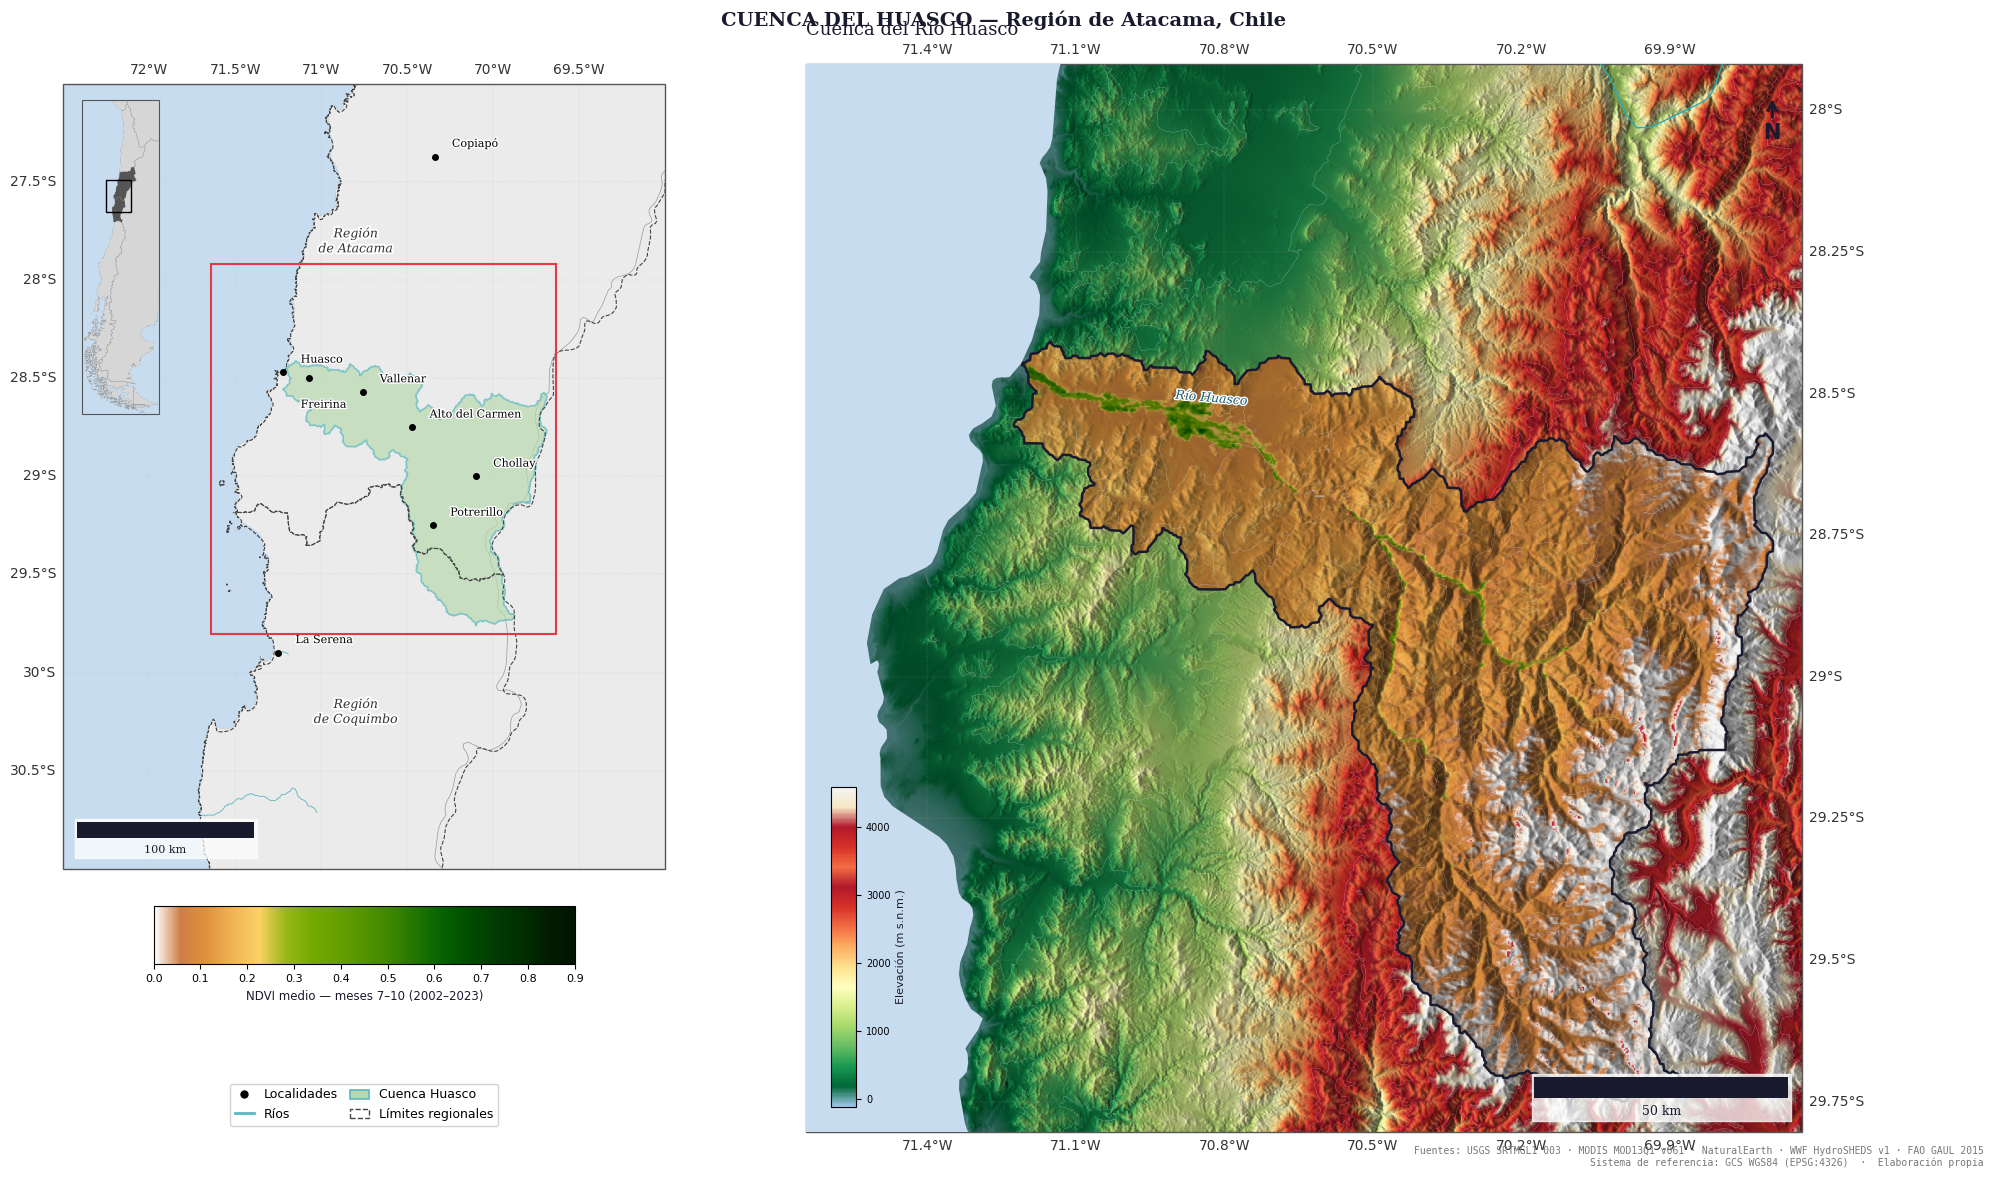

✅ Layout generado.


In [18]:
import matplotlib.gridspec as gridspec
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
import cartopy.feature as cfeature

CRS = ccrs.PlateCarree()
BG  = '#FFFFFF'

EXT_MAIN = [dem_ext[0], dem_ext[1], dem_ext[2], dem_ext[3]]
EXT_REG  = [-72.5, -69.0, -31.0, -27.0]
EXT_CHL  = [-76.0, -65.0, -56.0, -17.0]

rivers = cfeature.NaturalEarthFeature(
    category='physical', name='rivers_lake_centerlines',
    scale='10m', facecolor='none'
)

# ── Colormaps ─────────────────────────────────────────────────────────────────
paleta_elev = [
    '#9fc5e8', '#006837', '#1a9850', '#66bd63', '#a6d96a',
    '#d9ef8b', '#ffffbf', '#fee08b', '#fdae61', '#f46d43',
    '#d73027', '#b2182b', '#f46d43', '#d73027', '#b2182b',
    '#f6e8c3', '#f5f5f5'
]
paleta_ndvi = [
    '#ffffff', '#ce7e45', '#df923d', '#f1b555', '#fcd163', '#99b718',
    '#74a901', '#66a000', '#529400', '#3e8601', '#207401', '#056201',
    '#004c00', '#023b01', '#012e01', '#011d01', '#011301'
]
sm_elev = ScalarMappable(
    cmap=LinearSegmentedColormap.from_list('elev', paleta_elev),
    norm=mcolors.Normalize(vmin=-120, vmax=4600)
)
sm_elev.set_array([])
sm_ndvi = ScalarMappable(
    cmap=LinearSegmentedColormap.from_list('ndvi', paleta_ndvi),
    norm=mcolors.Normalize(vmin=0, vmax=0.9)
)
sm_ndvi.set_array([])

# ── Figura: 2 columnas, 2 filas ───────────────────────────────────────────────
fig = plt.figure(figsize=(20, 12), facecolor=BG)
gs = gridspec.GridSpec(
    2, 2,
    width_ratios=[0.32, 0.68],
    height_ratios=[0.78, 0.22],
    hspace=0.02, wspace=0.0,
    left=0.03, right=0.97, top=0.93, bottom=0.04
)

# ══════════════════════════════════════════════════════════════════════════════
# PANEL IZQUIERDO — Regional (fila 0, col 0)
# ══════════════════════════════════════════════════════════════════════════════
ax_reg = fig.add_subplot(gs[0, 0], projection=CRS, facecolor='#C8DCF0')
ax_reg.set_extent(EXT_REG, crs=CRS)

ax_reg.add_feature(cfeature.LAND,    facecolor='#EBEBEB', edgecolor='#aaa', linewidth=0.3)
ax_reg.add_feature(cfeature.OCEAN,   facecolor='#C8DCF0')
ax_reg.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='#999')

rios_gdf.plot(ax=ax_reg, color='#5BB8C1', linewidth=0.6, zorder=3, transform=CRS)
huasco_gdf.plot(ax=ax_reg, color='#B8D9B0', edgecolor='#5BB8C1',
                linewidth=1.2, zorder=4, transform=CRS, alpha=0.7)
regiones_gdf.boundary.plot(ax=ax_reg, color='#444', linewidth=0.8,
                            linestyle='--', zorder=5, transform=CRS)

# Nombres de regiones
nombres_regiones = {
    'Región\nde Atacama':  (-70.8, -27.8),
    'Región\nde Coquimbo': (-70.8, -30.2),
}
for nombre, (lon, lat) in nombres_regiones.items():
    ax_reg.text(lon, lat, nombre, fontsize=9, fontstyle='italic',
                fontfamily='serif', color='#333', ha='center', va='center',
                transform=CRS, zorder=6,
                path_effects=[pe.withStroke(linewidth=2.8, foreground='white')])

# Ciudades — (lon, lat, dlon, dlat)
ciudades_reg = {
    'Vallenar':        (-70.76, -28.57, +0.10, +0.05),
    'Copiapó':         (-70.34, -27.37, +0.10, +0.05),
    'Freirina':        (-71.07, -28.50, -0.05, -0.15),
    'Huasco':          (-71.22, -28.47, +0.10, +0.05),
    'La Serena':       (-71.25, -29.90, +0.10, +0.05),
    'Alto del Carmen': (-70.47, -28.75, +0.10, +0.05),
    'Chollay':         (-70.10, -29.00, +0.10, +0.05),
    'Potrerillo':      (-70.35, -29.25, +0.10, +0.05),
}
for nombre, (lon, lat, dlon, dlat) in ciudades_reg.items():
    ax_reg.plot(lon, lat, 'ko', markersize=4, transform=CRS, zorder=7)
    ax_reg.text(lon + dlon, lat + dlat, nombre, fontsize=8,
                fontfamily='serif', transform=CRS, zorder=8,
                path_effects=[pe.withStroke(linewidth=2, foreground='white')])

# Cuadrícula panel izquierdo
gl_r = ax_reg.gridlines(draw_labels=True, linewidth=0.3,
                         color='#bbb', alpha=0.8, linestyle=':')
gl_r.top_labels    = True
gl_r.bottom_labels = False
gl_r.left_labels   = True
gl_r.right_labels  = False
gl_r.xformatter = LONGITUDE_FORMATTER
gl_r.yformatter = LATITUDE_FORMATTER
gl_r.xlabel_style = {'size': 10, 'color': '#333'}
gl_r.ylabel_style = {'size': 10, 'color': '#333'}

# Recuadro zoom
x0, x1, y0, y1 = EXT_MAIN
ax_reg.add_patch(Rectangle(
    (x0, y0), x1-x0, y1-y0,
    linewidth=1.5, edgecolor='#E63946', facecolor='none',
    transform=CRS, zorder=9
))

# Escala panel izquierdo
lat_centro_reg       = (EXT_REG[2] + EXT_REG[3]) / 2
metros_por_grado_reg = 111320 * np.cos(np.radians(lat_centro_reg))
ax_reg.add_artist(ScaleBar(
    metros_por_grado_reg, units='m',
    fixed_value=100, fixed_units='km',
    location='lower left',
    frameon=True, color='#1A1A2E',
    box_color='white', box_alpha=0.75,
    border_pad=0.8, sep=5, height_fraction=0.02,
    font_properties={'size': 8, 'family': 'serif'}
))

# Inset Chile
ax_chl = ax_reg.inset_axes([-0.08, 0.58, 0.35, 0.40], projection=CRS)
ax_chl.set_extent(EXT_CHL, crs=CRS)
ax_chl.add_feature(cfeature.LAND,    facecolor='#D6D6D6', edgecolor='#888', linewidth=0.3)
ax_chl.add_feature(cfeature.OCEAN,   facecolor='#C8DCF0')
ax_chl.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='#888')
regiones_gdf.plot(ax=ax_chl, color='#555', zorder=3, transform=CRS)
x0r, x1r, y0r, y1r = EXT_REG
ax_chl.add_patch(Rectangle(
    (x0r, y0r), x1r-x0r, y1r-y0r,
    linewidth=1.0, edgecolor='black', facecolor='none',
    transform=CRS, zorder=5
))
for spine in ax_chl.spines.values():
    spine.set_edgecolor('#555')
    spine.set_linewidth(0.8)

# ══════════════════════════════════════════════════════════════════════════════
# LEYENDA — debajo del panel izquierdo (fila 1, col 0)
# ══════════════════════════════════════════════════════════════════════════════
ax_leg = fig.add_subplot(gs[1, 0])
ax_leg.axis('off')

# Colorbar NDVI horizontal
cax_ndvi = inset_axes(ax_leg, width='70%', height='25%',
                       loc='upper center', borderpad=0.5)
cb_ndvi  = plt.colorbar(sm_ndvi, cax=cax_ndvi, orientation='horizontal')
cb_ndvi.set_label(
    f'NDVI medio — meses {MONTH_START}–{MONTH_END} ({YEAR_START}–{YEAR_END})',
    fontsize=8.5, color='#1A1A2E', labelpad=4
)
cb_ndvi.ax.tick_params(labelsize=8)

# Leyenda de símbolos
handles = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='k',
           markersize=7, label='Localidades'),
    Line2D([0],[0], color='#5BB8C1', linewidth=2, label='Ríos'),
    mpatches.Patch(facecolor='#B8D9B0', edgecolor='#5BB8C1',
                   linewidth=1.2, label='Cuenca Huasco'),
    mpatches.Patch(facecolor='none', edgecolor='#444',
                   linewidth=1, linestyle='--', label='Límites regionales'),
]
ax_leg.legend(handles=handles, loc='lower center', ncol=2,
              fontsize=9, frameon=True, framealpha=0.85,
              edgecolor='#ccc', bbox_to_anchor=(0.5, 0.0),
              columnspacing=1.0, handlelength=1.5)

# ══════════════════════════════════════════════════════════════════════════════
# PANEL PRINCIPAL — ocupa ambas filas col 1
# ══════════════════════════════════════════════════════════════════════════════
ax_main = fig.add_subplot(gs[:, 1], projection=CRS, facecolor='#C8DCF0')
ax_main.set_extent(EXT_MAIN, crs=CRS)

# DEM hillshade
ax_main.imshow(
    shaded_2d, extent=dem_ext, transform=CRS,
    origin='upper', interpolation='bilinear', zorder=1
)

# NDVI enmascarado (RGBA)
ax_main.imshow(
    ndvi_2d, extent=ndvi_ext, transform=CRS,
    origin='upper', interpolation='bilinear', zorder=2
)

# Curvas de nivel
lon_arr = np.linspace(dem_ext[0], dem_ext[1], dem_2d.shape[1])
lat_arr = np.linspace(dem_ext[3], dem_ext[2], dem_2d.shape[0])
LON, LAT = np.meshgrid(lon_arr, lat_arr)
ax_main.contour(LON, LAT, dem_2d,
                levels=[500, 1000, 2000, 3000, 4000],
                colors='white', linewidths=0.3, alpha=0.4, transform=CRS, zorder=3)

ax_main.add_feature(rivers, edgecolor='#2AA8B4', linewidth=1.0, zorder=4)
huasco_gdf.boundary.plot(ax=ax_main, color='#1A1A2E', linewidth=1.8,
                          zorder=5, transform=CRS)
ax_main.add_feature(cfeature.OCEAN, facecolor='#C8DCF0', zorder=6)

ax_main.text(-70.90, -28.52, 'Río Huasco', fontsize=9, color='#1A5F7A',
             fontstyle='italic', fontfamily='serif', transform=CRS, rotation=-5,
             path_effects=[pe.withStroke(linewidth=2, foreground='white')], zorder=8)

# Cuadrícula panel principal
gl_m = ax_main.gridlines(draw_labels=True, linewidth=0.35,
                          color='#999', alpha=0.7, linestyle=':')
gl_m.top_labels    = True
gl_m.bottom_labels = True
gl_m.left_labels   = False
gl_m.right_labels  = True
gl_m.xformatter = LONGITUDE_FORMATTER
gl_m.yformatter = LATITUDE_FORMATTER
gl_m.xlabel_style = {'size': 10, 'color': '#333'}
gl_m.ylabel_style = {'size': 10, 'color': '#333'}

ax_main.annotate('N', xy=(0.97, 0.97), xytext=(0.97, 0.93),
                  xycoords='axes fraction', fontsize=15,
                  ha='center', fontweight='bold', color='#1A1A2E',
                  arrowprops=dict(arrowstyle='->', color='#1A1A2E', lw=2.2))

# Escala panel principal
lat_centro       = (dem_ext[2] + dem_ext[3]) / 2
metros_por_grado = 111320 * np.cos(np.radians(lat_centro))
ax_main.add_artist(ScaleBar(
    metros_por_grado, units='m',
    fixed_value=50, fixed_units='km',
    location='lower right',
    frameon=True, color='#1A1A2E',
    box_color='white', box_alpha=0.75,
    border_pad=0.8, sep=5, height_fraction=0.02,
    font_properties={'size': 9, 'family': 'serif'}
))

# Colorbar elevación
cax_elev = inset_axes(ax_main, width='2.5%', height='30%', loc='lower left', borderpad=1.8)
cb_elev  = plt.colorbar(sm_elev, cax=cax_elev)
cb_elev.set_label('Elevación (m s.n.m.)', fontsize=8, color='#1A1A2E')
cb_elev.ax.tick_params(labelsize=7)

ax_main.set_title('Cuenca del Río Huasco', fontsize=13,
                   fontfamily='serif', loc='left', pad=6, color='#1A1A2E')

# ══════════════════════════════════════════════════════════════════════════════
# TÍTULO Y CRÉDITOS
# ══════════════════════════════════════════════════════════════════════════════
fig.text(0.99, 0.01,
    'Fuentes: USGS SRTMGL1 003 · MODIS MOD13Q1 v061 · NaturalEarth · WWF HydroSHEDS v1 · FAO GAUL 2015\n'
    'Sistema de referencia: GCS WGS84 (EPSG:4326)  ·  Elaboración propia',
    ha='right', va='bottom', fontsize=7, color='#777', fontfamily='monospace')

fig.text(0.5, 0.975, 'CUENCA DEL HUASCO — Región de Atacama, Chile',
         ha='center', va='top', fontsize=14, fontweight='bold',
         color='#1A1A2E', fontfamily='serif')

for ax in [ax_reg, ax_main]:
    for spine in ax.spines.values():
        spine.set_edgecolor('#555')
        spine.set_linewidth(1.0)

# Rotar etiquetas Y manualmente tras renderizar
fig.canvas.draw()
for label in gl_r.left_label_artists:
    label.set_rotation(90)
    label.set_ha('center')
    label.set_va('bottom')
for label in gl_m.right_label_artists:
    label.set_rotation(90)
    label.set_ha('center')
    label.set_va('bottom')

plt.show()
print('✅ Layout generado.')

## 6 · Exportar mapa a PNG (300 DPI)

In [19]:
OUT = '/content/cartografia_huasco.png'

fig.savefig(OUT, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
print(f'✅ Guardado en: {OUT}')

from google.colab import files
files.download(OUT)

✅ Guardado en: /content/cartografia_huasco.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>